## Data preprocessing

In [98]:
import pandas as pd
from sklearn.model_selection import train_test_split
import xgboost as xgb
import joblib
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report , f1_score
import numpy as np
from imblearn.combine import SMOTETomek



In [37]:
df = pd.read_csv('credit_risk_dataset.csv')


In [38]:
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [39]:
df.tail()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
32576,57,53000,MORTGAGE,1.0,PERSONAL,C,5800,13.16,0,0.11,N,30
32577,54,120000,MORTGAGE,4.0,PERSONAL,A,17625,7.49,0,0.15,N,19
32578,65,76000,RENT,3.0,HOMEIMPROVEMENT,B,35000,10.99,1,0.46,N,28
32579,56,150000,MORTGAGE,5.0,PERSONAL,B,15000,11.48,0,0.10,N,26
32580,66,42000,RENT,2.0,MEDICAL,B,6475,9.99,0,0.15,N,30


In [40]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  str    
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  str    
 5   loan_grade                  32581 non-null  str    
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  str    
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), str(4)
memory usage: 3.0 MB


In [41]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [42]:
df.isnull().sum()   

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

In [43]:
df_filled = df.fillna({'person_emp_length': df['person_emp_length'].fillna(0)})

In [44]:
df_filled.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,32581.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.658114,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.159669,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [45]:
df_filtered = df_filled[(df_filled['person_age'] >= 18) & (df_filled['person_age'] <= 100)]

In [46]:
df_filtered.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32576.000000,3.257600e+04,32576.000000,32576.000000,29461.000000,32576.000000,32576.000000,32576.000000
mean,27.718044,6.588214e+04,4.657938,9589.117755,11.011547,0.218197,0.170212,5.803966
std,6.204990,5.253499e+04,4.159740,6321.886846,3.240623,0.413029,0.106778,4.053791
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,94.000000,2.039784e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [47]:
df_filtered = df_filtered[(df_filtered['person_emp_length'] >= 0) & (df_filtered['person_emp_length'] <= df_filtered['person_age']-18) & (df_filtered['person_emp_length'] <= 60)]

In [48]:
df_filtered.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,24740.000000,2.474000e+04,24740.000000,24740.000000,22395.000000,24740.000000,24740.000000,24740.000000
mean,28.636702,6.452278e+04,3.346888,9383.022433,11.088223,0.228941,0.171659,6.336459
std,6.604346,5.542144e+04,3.304647,6210.758561,3.214958,0.420160,0.107100,4.309058
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,24.000000,3.610000e+04,1.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,27.000000,5.400000e+04,3.000000,8000.000000,11.110000,0.000000,0.150000,5.000000
75%,32.000000,7.700000e+04,5.000000,12000.000000,13.480000,0.000000,0.230000,9.000000
max,94.000000,2.039784e+06,41.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [49]:
df_filtered.shape

(24740, 12)

In [50]:
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [51]:
columns_to_encode = ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']
df_encoded = pd.get_dummies(df_filtered, columns=columns_to_encode, drop_first=True).astype('float64')

In [52]:
df_encoded.head(20)

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length,person_home_ownership_OTHER,person_home_ownership_OWN,...,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,loan_grade_B,loan_grade_C,loan_grade_D,loan_grade_E,loan_grade_F,loan_grade_G,cb_person_default_on_file_Y
2,25.0,9600.0,1.0,5500.0,12.87,1.0,0.57,3.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,23.0,65500.0,4.0,35000.0,15.23,1.0,0.53,2.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
5,21.0,9900.0,2.0,2500.0,7.14,1.0,0.25,2.0,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,26.0,77100.0,8.0,35000.0,12.42,1.0,0.45,3.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
7,24.0,78956.0,5.0,35000.0,11.11,1.0,0.44,4.0,0.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
11,21.0,10000.0,2.0,4500.0,8.63,1.0,0.45,2.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
12,23.0,95000.0,2.0,35000.0,7.90,1.0,0.37,2.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
13,26.0,108160.0,4.0,35000.0,18.39,1.0,0.32,4.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
14,23.0,115000.0,2.0,35000.0,7.90,0.0,0.30,4.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
16,23.0,120000.0,0.0,35000.0,7.90,0.0,0.29,4.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [53]:
df_encoded.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length,person_home_ownership_OTHER,person_home_ownership_OWN,...,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,loan_grade_B,loan_grade_C,loan_grade_D,loan_grade_E,loan_grade_F,loan_grade_G,cb_person_default_on_file_Y
count,24740.000000,2.474000e+04,24740.000000,24740.000000,22395.000000,24740.000000,24740.000000,24740.000000,24740.000000,24740.000000,...,24740.000000,24740.000000,24740.000000,24740.000000,24740.000000,24740.000000,24740.00000,24740.000000,24740.000000,24740.000000
mean,28.636702,6.452278e+04,3.346888,9383.022433,11.088223,0.228941,0.171659,6.336459,0.003395,0.075627,...,0.190259,0.168876,0.173484,0.320210,0.204648,0.113177,0.03076,0.007882,0.001738,0.182053
std,6.604346,5.542144e+04,3.304647,6210.758561,3.214958,0.420160,0.107100,4.309058,0.058171,0.264405,...,0.392513,0.374650,0.378673,0.466567,0.403453,0.316815,0.17267,0.088432,0.041655,0.385896
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
25%,24.000000,3.610000e+04,1.000000,5000.000000,7.900000,0.000000,0.090000,3.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
50%,27.000000,5.400000e+04,3.000000,8000.000000,11.110000,0.000000,0.150000,5.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
75%,32.000000,7.700000e+04,5.000000,12000.000000,13.480000,0.000000,0.230000,9.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
max,94.000000,2.039784e+06,41.000000,35000.000000,23.220000,1.000000,0.830000,30.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000


In [54]:
df_encoded['loan_percent_income'] = df_encoded['loan_amnt'] / df_encoded['person_income']

In [55]:
df_encoded.head()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length,person_home_ownership_OTHER,person_home_ownership_OWN,...,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,loan_grade_B,loan_grade_C,loan_grade_D,loan_grade_E,loan_grade_F,loan_grade_G,cb_person_default_on_file_Y
2,25.0,9600.0,1.0,5500.0,12.87,1.0,0.572917,3.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,23.0,65500.0,4.0,35000.0,15.23,1.0,0.534351,2.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
5,21.0,9900.0,2.0,2500.0,7.14,1.0,0.252525,2.0,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,26.0,77100.0,8.0,35000.0,12.42,1.0,0.453956,3.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
7,24.0,78956.0,5.0,35000.0,11.11,1.0,0.443285,4.0,0.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


In [56]:
df_encoded.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length,person_home_ownership_OTHER,person_home_ownership_OWN,...,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,loan_grade_B,loan_grade_C,loan_grade_D,loan_grade_E,loan_grade_F,loan_grade_G,cb_person_default_on_file_Y
count,24740.000000,2.474000e+04,24740.000000,24740.000000,22395.000000,24740.000000,24740.000000,24740.000000,24740.000000,24740.000000,...,24740.000000,24740.000000,24740.000000,24740.000000,24740.000000,24740.000000,24740.00000,24740.000000,24740.000000,24740.000000
mean,28.636702,6.452278e+04,3.346888,9383.022433,11.088223,0.228941,0.171979,6.336459,0.003395,0.075627,...,0.190259,0.168876,0.173484,0.320210,0.204648,0.113177,0.03076,0.007882,0.001738,0.182053
std,6.604346,5.542144e+04,3.304647,6210.758561,3.214958,0.420160,0.107332,4.309058,0.058171,0.264405,...,0.392513,0.374650,0.378673,0.466567,0.403453,0.316815,0.17267,0.088432,0.041655,0.385896
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000789,2.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
25%,24.000000,3.610000e+04,1.000000,5000.000000,7.900000,0.000000,0.090909,3.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
50%,27.000000,5.400000e+04,3.000000,8000.000000,11.110000,0.000000,0.150000,5.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
75%,32.000000,7.700000e+04,5.000000,12000.000000,13.480000,0.000000,0.230769,9.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
max,94.000000,2.039784e+06,41.000000,35000.000000,23.220000,1.000000,0.830000,30.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000


In [57]:
(df_encoded["loan_int_rate"] == 0).sum()

np.int64(0)

In [58]:
for col in df_encoded["loan_int_rate"]:
    if col == 0:
        df_encoded["loan_int_rate"] = df_encoded["loan_int_rate"].replace(0, df_encoded["loan_int_rate"].mean())
         

In [59]:
(df_encoded["loan_int_rate"] == 0).sum()

np.int64(0)

In [60]:
df_encoded.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length,person_home_ownership_OTHER,person_home_ownership_OWN,...,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,loan_grade_B,loan_grade_C,loan_grade_D,loan_grade_E,loan_grade_F,loan_grade_G,cb_person_default_on_file_Y
count,24740.000000,2.474000e+04,24740.000000,24740.000000,22395.000000,24740.000000,24740.000000,24740.000000,24740.000000,24740.000000,...,24740.000000,24740.000000,24740.000000,24740.000000,24740.000000,24740.000000,24740.00000,24740.000000,24740.000000,24740.000000
mean,28.636702,6.452278e+04,3.346888,9383.022433,11.088223,0.228941,0.171979,6.336459,0.003395,0.075627,...,0.190259,0.168876,0.173484,0.320210,0.204648,0.113177,0.03076,0.007882,0.001738,0.182053
std,6.604346,5.542144e+04,3.304647,6210.758561,3.214958,0.420160,0.107332,4.309058,0.058171,0.264405,...,0.392513,0.374650,0.378673,0.466567,0.403453,0.316815,0.17267,0.088432,0.041655,0.385896
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000789,2.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
25%,24.000000,3.610000e+04,1.000000,5000.000000,7.900000,0.000000,0.090909,3.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
50%,27.000000,5.400000e+04,3.000000,8000.000000,11.110000,0.000000,0.150000,5.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
75%,32.000000,7.700000e+04,5.000000,12000.000000,13.480000,0.000000,0.230769,9.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
max,94.000000,2.039784e+06,41.000000,35000.000000,23.220000,1.000000,0.830000,30.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000


In [61]:
df_encoded.head()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length,person_home_ownership_OTHER,person_home_ownership_OWN,...,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,loan_grade_B,loan_grade_C,loan_grade_D,loan_grade_E,loan_grade_F,loan_grade_G,cb_person_default_on_file_Y
2,25.0,9600.0,1.0,5500.0,12.87,1.0,0.572917,3.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,23.0,65500.0,4.0,35000.0,15.23,1.0,0.534351,2.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
5,21.0,9900.0,2.0,2500.0,7.14,1.0,0.252525,2.0,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,26.0,77100.0,8.0,35000.0,12.42,1.0,0.453956,3.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
7,24.0,78956.0,5.0,35000.0,11.11,1.0,0.443285,4.0,0.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


In [62]:
df_processed = df_encoded.drop(['cb_person_cred_hist_length'], axis=1)

In [63]:
df_processed.head()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,...,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,loan_grade_B,loan_grade_C,loan_grade_D,loan_grade_E,loan_grade_F,loan_grade_G,cb_person_default_on_file_Y
2,25.0,9600.0,1.0,5500.0,12.87,1.0,0.572917,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,23.0,65500.0,4.0,35000.0,15.23,1.0,0.534351,0.0,0.0,1.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
5,21.0,9900.0,2.0,2500.0,7.14,1.0,0.252525,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,26.0,77100.0,8.0,35000.0,12.42,1.0,0.453956,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
7,24.0,78956.0,5.0,35000.0,11.11,1.0,0.443285,0.0,0.0,1.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


In [64]:
X = df_processed.drop(['loan_status'], axis=1)
Y = df_processed['loan_status']

## Data visualization

In [65]:
import matplotlib.pyplot as plt

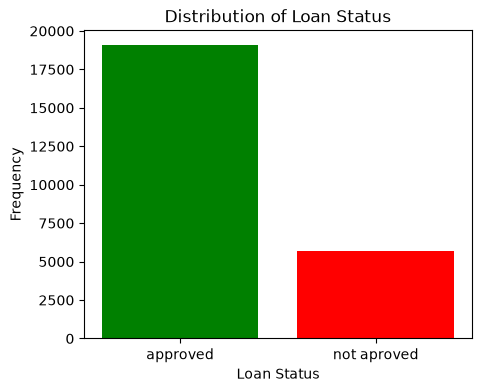

In [66]:
x = df_processed['loan_status']
plt.figure(figsize=(5,4))

counts = x.value_counts()
plt.bar(counts.index, counts.values, color=['green', 'red'])
plt.xticks(counts.index, ['approved', 'not aproved'])
plt.xlabel('Loan Status')
plt.ylabel('Frequency')
plt.title('Distribution of Loan Status')
plt.show()
 

Text(0.5, 1.0, 'Loan Amount vs Loan Status')

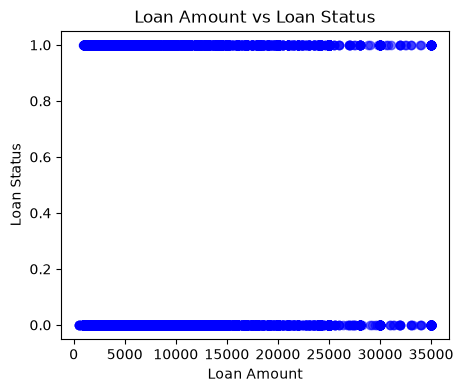

In [67]:
x = df_processed['loan_amnt']
y = df_processed['loan_status']

plt.figure(figsize=(5,4))
plt.scatter(x, y, alpha=0.5, color='blue')
plt.xlabel('Loan Amount')
plt.ylabel('Loan Status')
plt.title('Loan Amount vs Loan Status')
 

Text(0.5, 1.0, 'Loan Amount vs Loan Interest Rate')

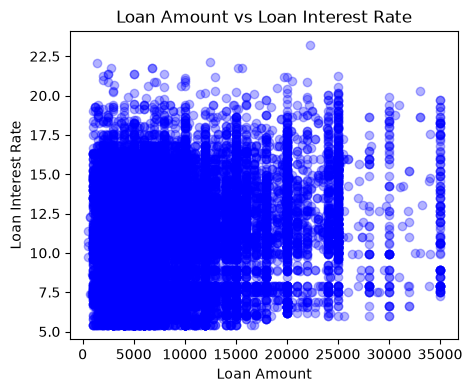

In [68]:
x = df_processed['loan_amnt']
y = df_processed['loan_int_rate']

plt.figure(figsize=(5,4))
plt.scatter(x, y, alpha=0.3, color='blue')
plt.xlabel('Loan Amount')
plt.ylabel('Loan Interest Rate')
plt.title('Loan Amount vs Loan Interest Rate')
 

## Train test split

In [69]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [100]:

from sklearn.impute import SimpleImputer

# 1. Initialize an imputer 
# Use 'median' for numeric data (robust to outliers)
imputer = SimpleImputer(strategy='median')

# If your X_train is a pandas DataFrame, imputing returns a numpy array. 
# We convert it back to a DataFrame to keep your column structure intact.
X_train_clean = pd.DataFrame(
    imputer.fit_transform(X_train), 
    columns=X_train.columns
)

# Remember to apply the same imputer to your test set later!
# X_test_clean = pd.DataFrame(imputer.transform(X_test), columns=X_test.columns)

# 2. Now run SMOTETomek on the cleaned data
smt = SMOTETomek(random_state=42)
X_train_res, y_train_res = smt.fit_resample(X_train_clean, Y_train)

print("Resampling complete! Rows before:", X_train.shape[0], "Rows after:", X_train_res.shape[0])


Resampling complete! Rows before: 19792 Rows after: 28426


## Model fitting

In [101]:

model = xgb.XGBClassifier(n_estimators=100, learning_rate=0.1)

model.fit(
    X_train_res,
    y_train_res,
    eval_set=[(X_train_res, y_train_res), (X_test, Y_test)],
    verbose=False
)


,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [102]:
results = model.evals_result()
print("Training Log Loss:", results['validation_0']['logloss'][-1])


Training Log Loss: 0.1059838811966844


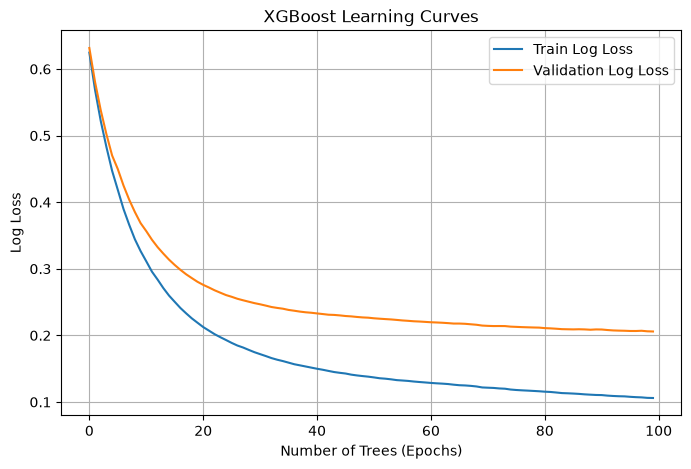

In [103]:
plt.figure(figsize=(8, 5))
plt.plot(results['validation_0']['logloss'], label='Train Log Loss')
plt.plot(results['validation_1']['logloss'], label='Validation Log Loss')
plt.title('XGBoost Learning Curves')
plt.xlabel('Number of Trees (Epochs)')
plt.ylabel('Log Loss')
plt.legend()
plt.grid(True)
plt.show()

In [79]:
results = model.evals_result()
train_logloss_history = results['validation_0']['logloss']
val_logloss_history = results['validation_1']['logloss']


final_train_loss = train_logloss_history[-1]
final_val_loss = val_logloss_history[-1]

print(f"Final Train Log Loss:      {final_train_loss:.4f}")
print(f"Final Validation Log Loss: {final_val_loss:.4f}")

loss_diff = final_val_loss - final_train_loss
if loss_diff > 0.10:
    print(f" WARNING: High risk of overfitting. Val loss is {loss_diff:.4f} higher than Train loss.")
elif final_train_loss < 0.02 and final_val_loss > 0.15:
    print(" WARNING: Severe overfitting. Model has nearly memorized the training set.")
else:
    print(" PASS: Train vs. Validation gaps look stable.")

Final Train Log Loss:      0.1679
Final Validation Log Loss: 0.1919
✅ PASS: Train vs. Validation gaps look stable.


In [104]:
print("\n--- DATA LEAKAGE DIAGNOSTIC ---")


importance_scores = model.get_booster().get_score(importance_type='gain')


importance_df = pd.DataFrame({
    'Feature': list(importance_scores.keys()),
    'Gain_Importance': list(importance_scores.values())
})
# Normalize to percentages for easier reading
importance_df['Importance_Pct'] = (importance_df['Gain_Importance'] / importance_df['Gain_Importance'].sum()) * 100
importance_df = importance_df.sort_values(by='Importance_Pct', ascending=False).reset_index(drop=True)

print("Top Feature Importances:")
print(importance_df.head(5).to_string(index=False))

top_feature_pct = importance_df.loc[0, 'Importance_Pct']
top_feature_name = importance_df.loc[0, 'Feature']

if top_feature_pct > 70.0:
    print(f"\n🚨 ALERT: Potential Data Leakage! '{top_feature_name}' holds {top_feature_pct:.1f}% of total model power.")
    print("Investigate whether this feature occurs chronologically *after* or directly reveals the target variable.")
else:
    print(f"\n✅ PASS: Feature distribution is healthy. Highest feature holds {top_feature_pct:.1f}% power.")


--- DATA LEAKAGE DIAGNOSTIC ---
Top Feature Importances:
                    Feature  Gain_Importance  Importance_Pct
               loan_grade_D       277.031982       24.440167
 person_home_ownership_RENT       153.050964       13.502380
        loan_percent_income       108.140846        9.540344
               loan_grade_E       103.850174        9.161815
cb_person_default_on_file_Y        64.327553        5.675071

✅ PASS: Feature distribution is healthy. Highest feature holds 24.4% power.


In [105]:
predictions = model.predict(X_test)

In [106]:
probabilities = model.predict_proba(X_test)

# 4. Evaluate Accuracy Results
accuracy = accuracy_score(Y_test, predictions)
conf_matrix = confusion_matrix(Y_test, predictions)

print("--- XGBoost Classification Results ---")
print(f"Overall Accuracy: {accuracy * 100:.2f}%")

print("\nFirst 5 Raw Predictions vs Probabilities:")
for i in range(5):
    print(f"Sample {i+1}: Predicted Class = {predictions[i]} | Probabilities = [Class 0: {probabilities[i][0]:.2f}, Class 1: {probabilities[i][1]:.2f}]")

print("\nConfusion Matrix Grid:\n", conf_matrix)
print("\nDetailed Breakdown:\n", classification_report(Y_test, predictions))

--- XGBoost Classification Results ---
Overall Accuracy: 93.17%

First 5 Raw Predictions vs Probabilities:
Sample 1: Predicted Class = 0 | Probabilities = [Class 0: 1.00, Class 1: 0.00]
Sample 2: Predicted Class = 1 | Probabilities = [Class 0: 0.03, Class 1: 0.97]
Sample 3: Predicted Class = 0 | Probabilities = [Class 0: 0.94, Class 1: 0.06]
Sample 4: Predicted Class = 0 | Probabilities = [Class 0: 0.83, Class 1: 0.17]
Sample 5: Predicted Class = 0 | Probabilities = [Class 0: 0.90, Class 1: 0.10]

Confusion Matrix Grid:
 [[3792   71]
 [ 267  818]]

Detailed Breakdown:
               precision    recall  f1-score   support

         0.0       0.93      0.98      0.96      3863
         1.0       0.92      0.75      0.83      1085

    accuracy                           0.93      4948
   macro avg       0.93      0.87      0.89      4948
weighted avg       0.93      0.93      0.93      4948



In [107]:
probabilities = model.predict_proba(X_test)[:, 1]

# Lower threshold from 0.50 to 0.35 to catch more Class 1 cases
custom_predictions = (probabilities >= 0.35).astype(int)

In [108]:
print("--- New Classification Results ---")
print(f"Overall Accuracy: {accuracy_score(Y_test, custom_predictions) * 100:.2f}%")

# 2. Print Confusion Matrix Grid
print("\nConfusion Matrix Grid:")
print(confusion_matrix(Y_test, custom_predictions))

# 3. Print Precision, Recall, and F1-Score Breakdown
print("\nDetailed Breakdown:")
print(classification_report(Y_test, custom_predictions))

--- New Classification Results ---
Overall Accuracy: 91.67%

Confusion Matrix Grid:
[[3689  174]
 [ 238  847]]

Detailed Breakdown:
              precision    recall  f1-score   support

         0.0       0.94      0.95      0.95      3863
         1.0       0.83      0.78      0.80      1085

    accuracy                           0.92      4948
   macro avg       0.88      0.87      0.88      4948
weighted avg       0.92      0.92      0.92      4948



In [109]:
best_threshold = 0.5
best_f1 = 0.0

for threshold in np.arange(0.01, 1.0, 0.01):
    preds = (probabilities >= threshold).astype(int)
    # Calculate F1-score specifically for Class 1
    score = f1_score(Y_test, preds, pos_label=1)
    
    if score > best_f1:
        best_f1 = score
        best_threshold = threshold

print(f"🥇 Optimal Threshold Found: {best_threshold:.2f}")
print(f"🚀 Max Class 1 F1-Score: {best_f1:.4f}\n")

# Apply the absolute best threshold found
optimized_preds = (probabilities >= best_threshold).astype(int)

# Print your new optimized results
print("--- Optimized Classification Results ---")
print("Confusion Matrix:\n", confusion_matrix(Y_test, optimized_preds))
print("\nClassification Report:\n", classification_report(Y_test, optimized_preds))

🥇 Optimal Threshold Found: 0.62
🚀 Max Class 1 F1-Score: 0.8360

--- Optimized Classification Results ---
Confusion Matrix:
 [[3837   26]
 [ 287  798]]

Classification Report:
               precision    recall  f1-score   support

         0.0       0.93      0.99      0.96      3863
         1.0       0.97      0.74      0.84      1085

    accuracy                           0.94      4948
   macro avg       0.95      0.86      0.90      4948
weighted avg       0.94      0.94      0.93      4948



In [83]:
joblib.dump(model, 'my_model.pkl')

['my_model.pkl']

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer, f1_score
 
# 1. Define the XGBoost base model with your class ratio
base_model = xgb.XGBClassifier(
    objective='binary:logistic',
    scale_pos_weight=3.56,  # Handles your 3863/1085 class ratio
    eval_metric='logloss',
    random_state=42
)

# 2. Set up the parameter grid specifically for imbalanced data
param_grid = {
    'max_depth': [4, 5, 6, 7],              # Shallowed trees prevent overfitting to noise
    'min_child_weight': [1, 3, 5],        # Higher values prevent tree creation on tiny noisy clusters
    'subsample': [0.7, 0.8, 1.0],         # Percentage of rows used per tree
    'colsample_bytree': [0.7, 0.8, 1.0]   # Percentage of columns used per tree
}

# 3. Create a custom scorer focused entirely on Class 1 F1-Score
f1_scorer = make_scorer(f1_score, pos_label=1)

# 4. Initialize and run the Grid Search using Stratified Cross-Validation
print("Starting grid search tuning... This may take a moment.")
grid_search = GridSearchCV(
    estimator=base_model,
    param_grid=param_grid,
    scoring=f1_scorer,
    cv=3,  # 3-Fold validation
    n_jobs=-1
)

# Fit on your training variables
grid_search.fit(X_train_res, y_train_res)

# 5. Output the winning combination
print(f"\n🥇 Best Parameters Found: {grid_search.best_params_}")
print(f"🚀 Best Validation F1-Score: {grid_search.best_score_:.4f}")

# Extract the optimized model for your final test predictions
best_model = grid_search.best_estimator_



SyntaxError: expression expected after dictionary key and ':' (289705602.py, line 14)